# Product Sales Prediction Using Linear Regression

## Objective
Predict product sales based on:

- Product information
- Customer demographics
- Purchase history
- Marketing factors
- Seasonal factors

Target Variable: sales_amount_log

Model: Linear Regression implemented from scratch using Gradient Descent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load Dataset

train_df = pd.read_csv("retail_train_80.csv")
test_df = pd.read_csv("retail_test_20.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(96000, 80)
(24000, 80)


,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,qty_roll_mean_30d,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,-0.691685,0,-0.541627,1,-14.478986,0,1,0,0,0,...,0,0,0,0,0,1,2024,1,1,0
1,0.064785,15,0.538838,3,-14.478986,0,0,1,0,1,...,0,1,0,0,0,0,2024,1,1,0
2,-0.121140,5,-0.136904,4,-14.478986,1,0,0,0,0,...,1,0,0,0,1,0,2024,1,1,0
3,0.064785,0,0.024365,1,-14.478986,0,1,0,0,0,...,1,0,0,0,1,0,2024,1,1,0
4,-0.121140,0,-0.087266,3,-14.478986,0,1,0,0,0,...,1,0,0,0,0,1,2024,1,1,0


In [ ]:
# Data Exploration (chứng minh no data detect)

train_df.info()

train_df.isnull().sum().sum()

<class 'pandas.DataFrame'>
RangeIndex: 96000 entries, 0 to 95999
Data columns (total 80 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unit_price                      96000 non-null  float64
 1   discount_pct                    96000 non-null  int64  
 2   sales_amount_log                96000 non-null  float64
 3   customer_age_group_encoded      96000 non-null  int64  
 4   qty_roll_mean_30d               96000 non-null  float64
 5   customer_gender_Female          96000 non-null  int64  
 6   customer_gender_Male            96000 non-null  int64  
 7   customer_gender_Other           96000 non-null  int64  
 8   customer_segment_Loyal          96000 non-null  int64  
 9   customer_segment_New            96000 non-null  int64  
 10  customer_segment_Returning      96000 non-null  int64  
 11  customer_segment_VIP            96000 non-null  int64  
 12  product_name_Bedsheet           96000 non-n

np.int64(0)

In [ ]:
# Thống kê mô tả data
train_df.describe()


,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,qty_roll_mean_30d,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
count,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,...,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000,96000.000000
mean,0.002735,5.508958,0.001618,2.003604,-0.014609,0.334417,0.331771,0.333813,0.250240,0.250844,...,0.331219,0.202135,0.197260,0.199240,0.200937,0.200427,2024.373938,5.613927,15.602927,3.000104
std,1.000385,8.201054,1.000091,1.414312,1.043436,0.471789,0.470852,0.471576,0.433153,0.433501,...,0.470654,0.401595,0.397933,0.399431,0.400703,0.400322,0.483850,3.221591,8.856371,2.001177
min,-1.590178,0.000000,-3.542983,0.000000,-14.478986,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024.000000,1.000000,1.000000,0.000000
25%,-0.937219,0.000000,-0.558193,1.000000,-0.559297,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024.000000,3.000000,8.000000,1.000000
50%,-0.012780,0.000000,0.187533,2.000000,-0.020891,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024.000000,5.000000,16.000000,3.000000
75%,0.944842,10.000000,0.618355,3.000000,0.546093,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2025.000000,8.000000,23.000000,5.000000
max,1.726713,30.000000,2.247125,4.000000,7.314466,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2025.000000,12.000000,31.000000,6.000000


In [ ]:
# Data Preparation

target = "sales_amount_log"

# TRAIN DATA
X_train = train_df.drop(
    columns=[target]
).values.astype(float)

y_train = train_df[target].values.astype(float)


# TEST DATA
X_test = test_df.drop(
    columns=[target]
).values.astype(float)

y_test = test_df[target].values.astype(float)

In [ ]:
# Feature Scaling (chuẩn hoá dữ liệu)
# chuẩn hóa về mean = 0 và standard deviation = 1 giúp quá trình tối ưu hội tụ nhanh hơn và ổn định hơn.

X_mean = np.mean(X_train, axis=0)

X_std = np.std(X_train, axis=0)

X_train = (X_train - X_mean) / (X_std + 1e-8)

X_test = (X_test - X_mean) / (X_std + 1e-8) #test dùng mean/std của train để tránh data leakage.

In [ ]:
# Custom linear regression

class LinearRegression:

    def __init__(self, learning_rate=0.01, epochs=750):
        self.lr = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape #Lấy kích thước
        # Khởi tạo trọng số
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):

            y_pred = np.dot(X, self.weights) + self.bias

            error = y_pred - y

            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = np.mean(error ** 2)
            self.loss_history.append(loss) #lưu để vẽ biểu đồ

            if epoch % 20 == 0:
                print(
                    f"Epoch {epoch:4d} | MSE = {loss:.6f}"
                )

    def predict(self, X):
        return (np.dot(X, self.weights) + self.bias) #CT Linear Regression

In [7]:
# Evaluation Metrics

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)

    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

In [40]:
# Train Model

model = LinearRegression(learning_rate=0.01,epochs=750)

print("Training...")

model.fit(X_train, y_train)

Training...
Epoch    0 | MSE = 1.000175
Epoch   20 | MSE = 0.586877
Epoch   40 | MSE = 0.444618
Epoch   60 | MSE = 0.385105
Epoch   80 | MSE = 0.354913
Epoch  100 | MSE = 0.337208
Epoch  120 | MSE = 0.325887
Epoch  140 | MSE = 0.318314
Epoch  160 | MSE = 0.313136
Epoch  180 | MSE = 0.309557
Epoch  200 | MSE = 0.307070
Epoch  220 | MSE = 0.305338
Epoch  240 | MSE = 0.304130
Epoch  260 | MSE = 0.303286
Epoch  280 | MSE = 0.302697
Epoch  300 | MSE = 0.302285
Epoch  320 | MSE = 0.301998
Epoch  340 | MSE = 0.301797
Epoch  360 | MSE = 0.301656
Epoch  380 | MSE = 0.301558
Epoch  400 | MSE = 0.301490
Epoch  420 | MSE = 0.301442
Epoch  440 | MSE = 0.301408
Epoch  460 | MSE = 0.301385
Epoch  480 | MSE = 0.301368
Epoch  500 | MSE = 0.301357
Epoch  520 | MSE = 0.301349
Epoch  540 | MSE = 0.301343
Epoch  560 | MSE = 0.301340
Epoch  580 | MSE = 0.301337
Epoch  600 | MSE = 0.301335
Epoch  620 | MSE = 0.301334
Epoch  640 | MSE = 0.301333
Epoch  660 | MSE = 0.301332
Epoch  680 | MSE = 0.301332
Epoch  7

In [ ]:
# Prediction: Dùng trọng số đã học để dự đoán dữ liệu mới
predictions = model.predict(X_test)

In [14]:
# Evaluation Results
results = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R²"
    ],
    "Value": [
        mse(y_test,predictions),
        rmse(y_test,predictions),
        mae(y_test,predictions),
        r2_score(y_test,predictions)
    ]
})

results

,Metric,Value
0,MSE,0.302712
1,RMSE,0.550192
2,MAE,0.449496
3,R²,0.697063


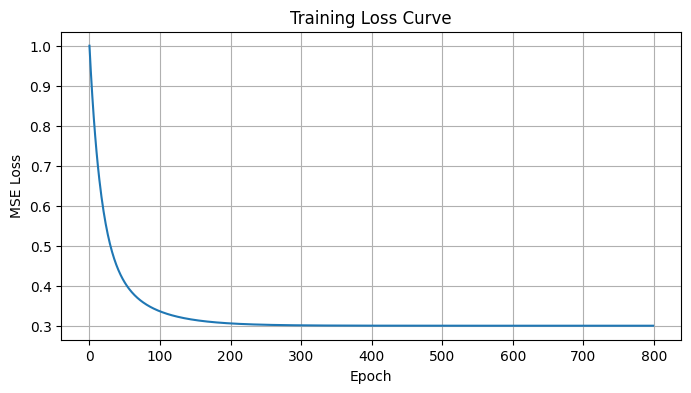

In [ ]:
# LOSS CURVE

plt.figure(figsize=(8,4))

plt.plot(model.loss_history)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

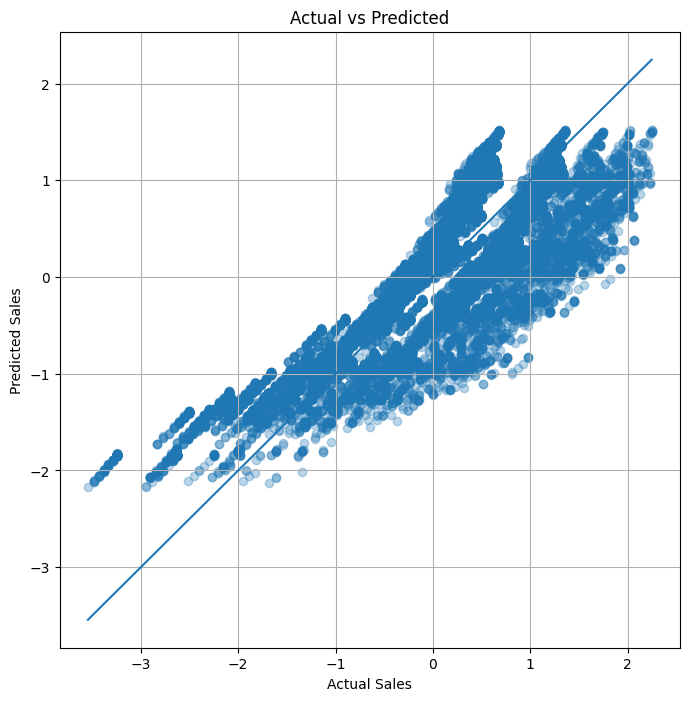

In [ ]:
# ACTUAL VS PREDICTED

# Đường vẽ lý tưởng: y = x
# Nếu điểm nằm sát đường này => dự đoán tốt
plt.figure(figsize=(8,8))

plt.scatter(y_test, predictions, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

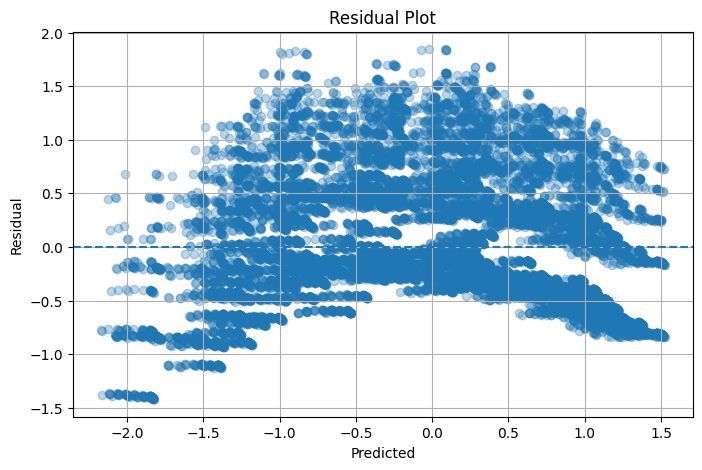

In [17]:
# 3. Residual Plot
residuals = y_test - predictions

plt.figure(figsize=(8,5))

plt.scatter( predictions, residuals, alpha=0.3)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

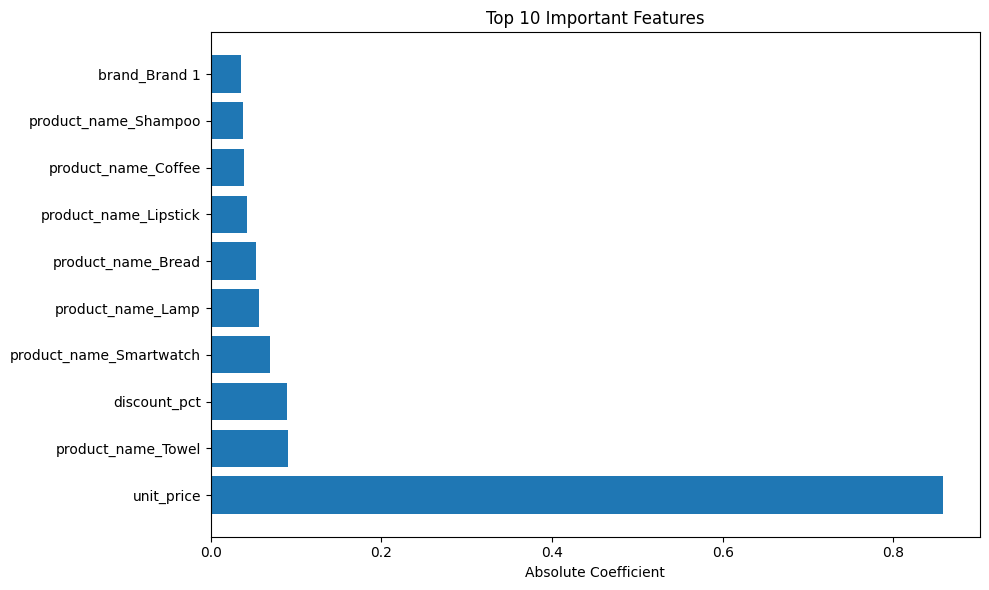

In [ ]:
# Top Feature Importance
feature_names = train_df.drop(
columns=[target]
).columns

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.weights
})

# Lấy trị tuyệt đối vì +10 và -10 đều ảnh hưởng mạnh như nhau
importance["AbsCoef"] = np.abs(importance["Coefficient"])

top10 = (importance.sort_values(
    by="AbsCoef",
    ascending=False
    ).head(10)
)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["AbsCoef"])

plt.xlabel("Absolute Coefficient")

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.show()